In [26]:
import numpy
import random
import torch

# set seed
seed = 47
random.seed(seed)
numpy.random.seed(seed)
torch.manual_seed(seed)

# Task
Prepare the "nielsr/CelebA-faces" dataset for VAE training by defining image transformations (resizing to 64x64 and converting to tensor), creating a custom PyTorch Dataset, and instantiating a PyTorch DataLoader.

## Define Image Transformations

Define the necessary image transformations using `torchvision.transforms` and converting them into PyTorch tensors.


In [27]:
from torchvision import transforms

image_transform = transforms.Compose([
    transforms.Resize((218, 178)),
    transforms.ToTensor(),
])

print("Image transformations defined successfully.")

Image transformations defined successfully.


## Create Custom Dataset

Implement a custom PyTorch `Dataset` class that wraps the loaded `CelebA-faces` dataset. This class will apply the defined transformations to each image when accessed.


In [28]:
from torch.utils.data import Dataset

class CelebADataset(Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset['train'] # Access the 'train' split of the loaded dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image = self.dataset[idx]['image']
        if self.transform:
            image = self.transform(image)
        return image

print("Custom CelebADataset class defined successfully.")

Custom CelebADataset class defined successfully.


## Create PyTorch DataLoader

### Subtask:
Instantiate the custom `CelebADataset` with the loaded dataset and the defined transformations. Then, create a PyTorch `DataLoader` using this dataset, specifying a batch size and enabling shuffling for training.

In [29]:
from datasets import load_dataset

ds = load_dataset("nielsr/CelebA-faces")

In [30]:
from torch.utils.data import DataLoader, random_split

batch_size = 32

celeba_dataset = CelebADataset(dataset=ds, transform=image_transform)

# SPLIT TO 70, 20, 10
train_size = int(0.7 * len(celeba_dataset))
val_size = int(0.2 * len(celeba_dataset))
test_size = len(celeba_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(celeba_dataset, [train_size, val_size, test_size])

# data loaders
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"CelebADataset instantiated with {len(celeba_dataset)} images.")
print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"DataLoaders created with batch size {batch_size} and shuffling enabled for training.")

CelebADataset instantiated with 202599 images.
Train dataset size: 141819
Validation dataset size: 40519
Test dataset size: 20261
DataLoaders created with batch size 32 and shuffling enabled for training.


Data Loader: batch_size x 3 x 218 x 178

In [31]:
for batch in train_dataloader:
  print(batch.shape)
  break

torch.Size([32, 3, 218, 178])


## Model Definition

In [ ]:
from torch import nn
class Encoder(nn.Module):
  def __init__(self, input_size, latent_variables):
    super(Encoder, self).__init__()
    self.input_size = input_size
    # to be of size 128*2 (for mean and log(variance))
    # conv layers with stride to gradually lower the dims to
    self.encoder = nn.Sequential(
        nn.Conv2d(input_size, 32, kernel_size=4, stride=2, padding=1), # bs x 32 x 109x 89
        nn.ReLU(),
        nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # bs x 64 x 54 x 44
        nn.ReLU(),
        nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # bs x 128 x 27 x 22
        nn.ReLU(),
        nn.Flatten(), # 32 x 27*22*128
        nn.Linear(27*22*128, 8*8*128),
        nn.ReLU(),
        nn.Linear(8*8*128, latent_variables*3),
        nn.ReLU(),
        nn.Linear(latent_variables*3, latent_variables*2), # (32, 256)  # latent space parameters (mean, sigma) ==> (32, 256)
    )
  def forward(self, x):
    return self.encoder(x)

class Decoder(nn.Module):
  def __init__(self, latent_dim, output_channels):
    super(Decoder, self).__init__()
    self.decoder = nn.Sequential(
        nn.Linear(latent_dim, 8*128), # bsx 128*8
        nn.ReLU(),
        nn.Linear(8*128, 8*8*128), # bsx 128*8*8
        nn.ReLU(),
        nn.Linear(8*8*128, 27*22*128), # bsx 128*8*8
        nn.ReLU(),
        nn.Unflatten(1, (128, 27, 22)), # Reshape to 128 channels, 8x8
        nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
        nn.ReLU(),
        nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
        nn.ReLU(),
        nn.ConvTranspose2d(32, output_channels, kernel_size=4, stride=2, padding=0), # Changed padding from 1 to 0
        nn.Sigmoid() # Output pixel values between 0 and 1
    )
  def forward(self, x):
    return self.decoder(x)

## Training :)

In [ ]:
from torchvision.models import vgg16

# Load pretrained VGG, take first few layers, freeze weights
vgg = vgg16(pretrained=True).to('cuda').features[:16].eval()
for p in vgg.parameters():
    p.requires_grad = False

def perceptual_loss(recon, target):
    return F.mse_loss(vgg(recon), vgg(target))

Epoch [1/12]: 100%|██████████| 4432/4432 [09:30<00:00,  7.76it/s, loss=3.71e+3]


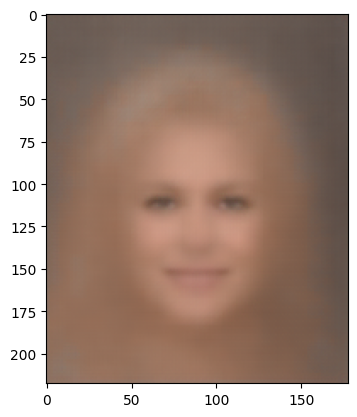

Epoch [2/12]: 100%|██████████| 4432/4432 [09:30<00:00,  7.76it/s, loss=2.72e+3]


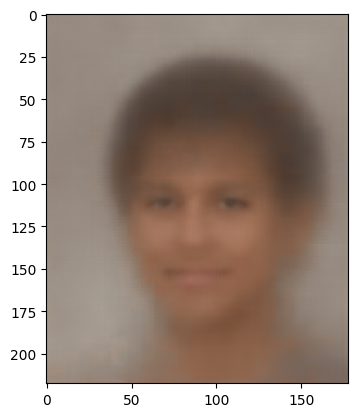

Epoch [3/12]: 100%|██████████| 4432/4432 [09:31<00:00,  7.76it/s, loss=3e+3]


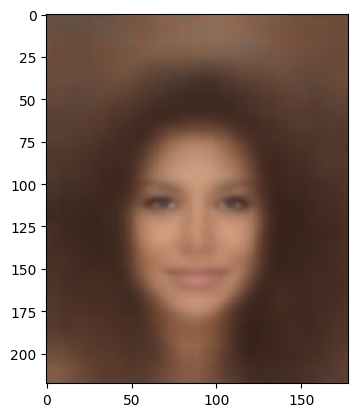

Epoch [4/12]: 100%|██████████| 4432/4432 [09:30<00:00,  7.76it/s, loss=2.45e+3]


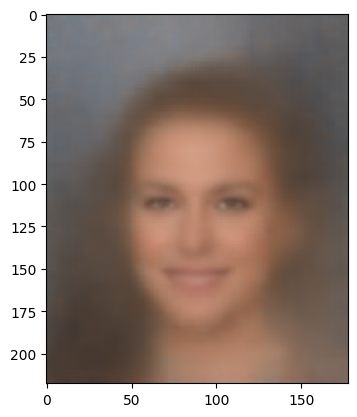

Epoch [5/12]: 100%|██████████| 4432/4432 [09:31<00:00,  7.76it/s, loss=2.42e+3]


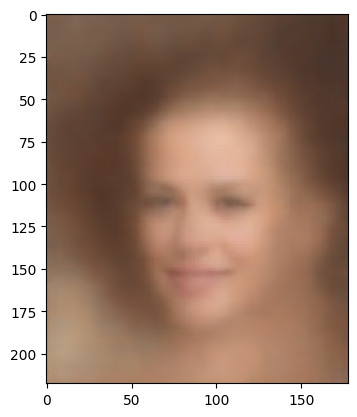

Epoch [6/12]: 100%|██████████| 4432/4432 [09:31<00:00,  7.76it/s, loss=2.37e+3]


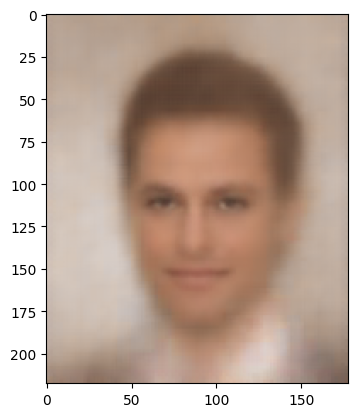

Epoch [7/12]: 100%|██████████| 4432/4432 [09:30<00:00,  7.76it/s, loss=2.83e+3]


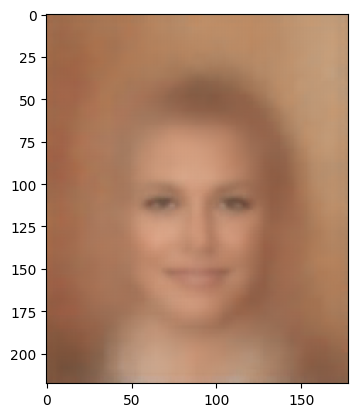

Epoch [8/12]: 100%|██████████| 4432/4432 [09:31<00:00,  7.76it/s, loss=2.36e+3]


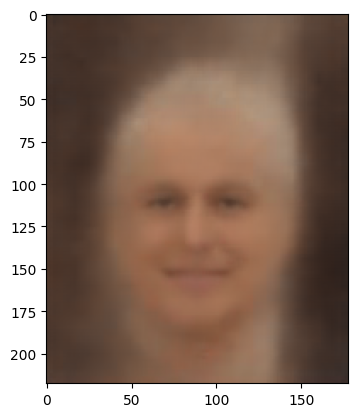

Epoch [9/12]: 100%|██████████| 4432/4432 [09:31<00:00,  7.75it/s, loss=2.33e+3]


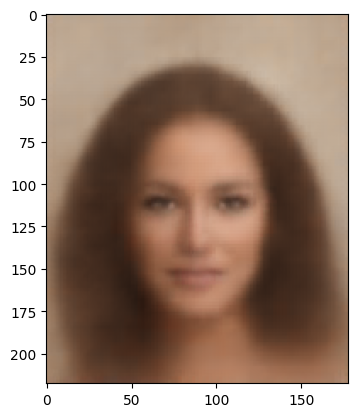

Epoch [10/12]: 100%|██████████| 4432/4432 [09:31<00:00,  7.76it/s, loss=2.07e+3]


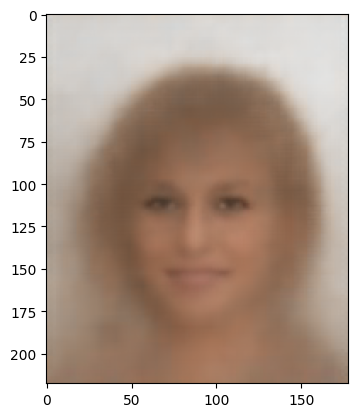

Epoch [11/12]: 100%|██████████| 4432/4432 [09:31<00:00,  7.76it/s, loss=2.3e+3]


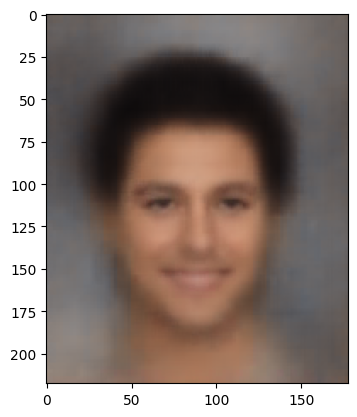

Epoch [12/12]: 100%|██████████| 4432/4432 [09:31<00:00,  7.75it/s, loss=2.4e+3]


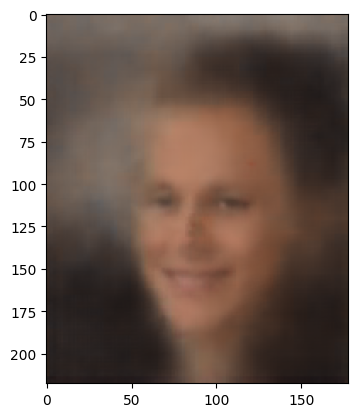

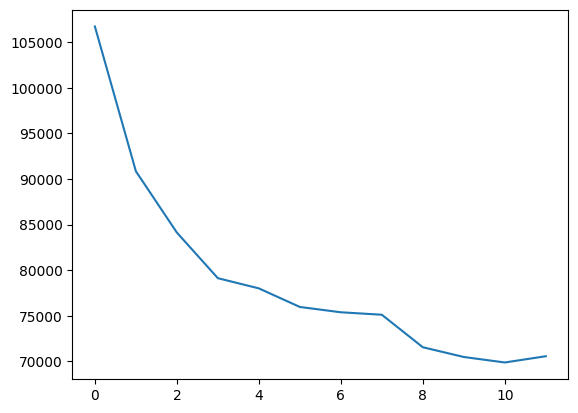

In [ ]:
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt

latent_factors = 200
encoder = Encoder(input_size=3, latent_variables=latent_factors).to(device='cuda')
decoder = Decoder(latent_dim=latent_factors, output_channels=3).to(device='cuda')
beta = 2
n_epochs = 12

# the training loop
optimizer = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=0.001)
test_loss_curve = []
for epoch in range(n_epochs):
  loop = tqdm(train_dataloader)
  test_loss_per_epoch = []
  encoder.train()
  decoder.train()
  for batch in loop: # batches over dataset
    # forward
    encoder_op = encoder(batch.to(device='cuda')) # (bs, 256)
    means, log_vars = encoder_op[:, :latent_factors], encoder_op[:, latent_factors:] # (bs, latent_factors), (bs, latent_factors)

    std = torch.exp(0.5 * log_vars) # (bs, 128)
    eps = torch.randn_like(std) # (bs, 128)
    z = eps * std + means # (bs, 128)

    reconstructed = decoder(z.to(device='cuda'))


    # compute loss
    KLD_loss = 0.5*(torch.sum(1 + 2*log_vars - means**2 - std**2, dim = 1)) # bs, 1
    # reconstructed = F.mse_loss(reconstructed, batch, reduction='sum') # bs, 1 ..... here L = 1 i.e. we sample 1 image for 1 z. practical limitations :)
    reconstructed = F.mse_loss(reconstructed, batch.to('cuda'), reduction='none').sum(dim=[1,2,3]) + 0.7 * perceptual_loss(reconstructed, batch.to('cuda'))  # sum over pixels, keep batch
    estimator = beta*KLD_loss - reconstructed # bs, 1

    # calculate gradient
    optimizer.zero_grad()
    loss = -estimator.mean()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(list(encoder.parameters()) + list(decoder.parameters()), max_norm=1.0)
    # update parameters
    optimizer.step()

    loop.set_description(f"Epoch [{epoch+1}/{n_epochs}]")
    loop.set_postfix(loss=loss.item())


  # test
  encoder.eval()
  decoder.eval()
  with torch.no_grad():
    for batch in test_dataloader:
      encoder_op = encoder(batch.to(device='cuda'))
      means, log_vars = encoder_op[:, :latent_factors], encoder_op[:, latent_factors:]
      std = torch.exp(0.5 * log_vars)
      eps = torch.randn_like(std)
      z = eps * std + means
      reconstructed = decoder(z)
      loss = F.mse_loss(reconstructed, batch.to('cuda'), reduction='sum')
      test_loss_per_epoch.append(loss.item())

  test_loss_curve.append(sum(test_loss_per_epoch)/len(test_loss_per_epoch))

  z = torch.randn(1, latent_factors)
  with torch.no_grad():
    reconstructed = decoder(z.to('cuda')).squeeze(0).cpu()

  # display image
  plt.imshow(reconstructed.squeeze().permute(1, 2, 0))
  plt.show()

# plot
plt.plot(test_loss_curve)

In [ ]:
# test decoder
z = torch.randn(1, 128)
decoder.eval()
with torch.no_grad():
  reconstructed = decoder(z.to('cuda')).squeeze(0).cpu()
print(reconstructed.shape)

# display image
import matplotlib.pyplot as plt
plt.imshow(reconstructed.squeeze().permute(1, 2, 0))
plt.show()

## SAVE MODEL

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
model_save_path = '/content/drive/MyDrive/Deep Learning/VAE/'
if not os.path.exists(model_save_path):
    os.makedirs(model_save_path)

encoder_path = os.path.join(model_save_path, 'encoder.pth')
decoder_path = os.path.join(model_save_path, 'decoder.pth')

torch.save(encoder.state_dict(), encoder_path)
torch.save(decoder.state_dict(), decoder_path)

print(f"Encoder saved to: {encoder_path}")
print(f"Decoder saved to: {decoder_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Encoder saved to: /content/drive/MyDrive/Deep Learning/VAE/encoder.pth
Decoder saved to: /content/drive/MyDrive/Deep Learning/VAE/decoder.pth


## Inference mode

torch.Size([3, 218, 178])


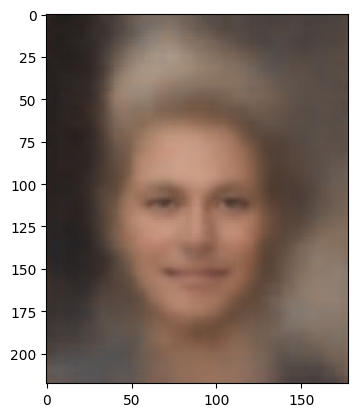

In [ ]:
## test decoder
z = torch.randn(1, 200)
decoder.eval()
with torch.no_grad():
  reconstructed = decoder(z.to('cuda')).squeeze(0).cpu()
print(reconstructed.shape)

# display image
import matplotlib.pyplot as plt
plt.imshow(reconstructed.squeeze().permute(1, 2, 0))
plt.show()